# Monte Carlo methods to estimate joint force distributions
We learned how reduction method can be used to calculate the joint reaction force at the elbow if all geometric variables (muscle force insertion angles, moment arms, muscle cross-sectional areas) are given.

What if we can't measure them for an individual, but have a good sense of population values?  Can we estimate a probability of a joint reaction force falling in a particular range?

Here we will work with the mean and standard deviation for our geometric variables to estimate the range of joint reaction forces generated in this simple motion.

**Extension:** we add a **fourth muscle** (force $F_4$, insertion angle $\theta_4$) acting about the same elbow joint, alongside the same reduction-method framework used for muscles 1-3. Muscle insertion angles, moment arms, and PCSA for all four muscles are perturbed as **normal distributions**, matching the original model.

**Population data substitution:** all population values below (PCSA, moment arm, insertion angle, and the book/load moment arm $c$) are now taken from Table 1 (elbow JRF problem muscle data) for four real elbow muscles -- **brachialis (BRA)**, **biceps brachii (BIC)**, **brachioradialis (BRD)**, and **pronator teres (PRO)** -- assigned to muscles 1-4 respectively.

### Assumptions made to complete this substitution
1. Table 1 reports **min/max ranges**, not mean/SD. We take mean = (min+max)/2 and SD = (max-min)/4, i.e. we assume the reported range spans roughly $\pm 2$ SD (about 95% of a normal distribution) around the mean.
2. Muscle-to-index mapping: M1 = brachialis (BRA), M2 = biceps brachii (BIC), M3 = brachioradialis (BRD), M4 = pronator teres (PRO). This assignment is arbitrary -- the physics/ratios are unaffected by which muscle is labeled M1-M4.
3. $F_B$ is given in Table 1 as a single fixed value (20 N), not a range, so it is treated as deterministic rather than sampled.
4. The load/book moment arm $c$ is sampled as normal (mean 33 cm, SD 4.5 cm) from Table 1's given range (24-42 cm), consistent with how the original model treated $c$.
5. Table 1 does not provide the forearm segment weight or its center-of-mass moment arm ($b$), so the original model's own internal relationship is kept unchanged: $b = c/2$ and $F_G = b\cdot(20/15)$ ("let weight of the ulna scale with the length of the ulna"), as in the initial file.
6. All four muscles' insertion angles, moment arms, and PCSA are sampled independently from normal distributions (as in the original file), each with the mean/SD derived from Table 1 per assumption 1.
7. Sample size nsam = 30, matching the original file's default.

**Sample-size sweep:** we repeat the full Monte Carlo simulation at three sample sizes -- n = 30, 70, and 100 -- printing the mean JRF magnitude and mean JRF angle for each, and plotting a separate histogram pair (JRF magnitude, JRF angle) per sample size.

**Isolating moment arm as the only varying independent variable:** the load moment arm $c$, all four insertion angles, and all four PCSA values are now held fixed at their Table 1 mean values (SD = 0); only the four muscle moment arms ($l_{M1}$-$l_{M4}$) are sampled from normal distributions. This isolates the moment arm's effect on the JRF from every other source of variability, while keeping the same normal-distribution family already used for moment arm in this version of the model.

**Joint angle fix:** the JRF angle is now computed with `np.arctan2(JointY, JointX)` instead of `np.arctan(JointY/JointX)`. The original `arctan(JointY/JointX)` loses quadrant information (it cannot tell $(+,+)$ from $(-,-)$, or $(+,-)$ from $(-,+)$) and is restricted to $(-90\deg, 90\deg)$. `arctan2` correctly resolves the quadrant from the signs of both components, and we wrap its result modulo $360\deg$ so the reported joint angle is always non-negative ($[0\deg, 360\deg)$).

**Latest iteration:** all independent variables ($c$, all four insertion angles, all four muscle moment arms, and all four PCSA values) are perturbed again -- each sampled independently from its own normal distribution -- reverting the moment-arm-only isolation. The JRF angle calculation is now factored into a standalone `positive_joint_angle()` function (quadrant-correct `arctan2`, wrapped modulo $360\deg$) so it is guaranteed non-negative and reusable.

**Correlating variables with muscle moment arm (instead of holding them at their mean):** rather than freezing $c$, insertion angle, and PCSA at fixed means to isolate moment arm, we now sample the four muscle moment arms first (independently, as before) and then parametrize every other independent variable as a function of moment arm plus independent noise, calibrated to a target Pearson correlation coefficient $\rho$.

### Assumptions used for the correlation structure
1. **No measured covariance data exists for this problem** -- Table 1 gives only each variable's marginal min/max range, with no joint/paired measurements across muscles or individuals. The correlation coefficients below are therefore *literature-informed judgment calls*, grounded in general anthropometric/allometric scaling reasoning, not values fitted to real paired data. They should be replaced with measured correlations if a real dataset becomes available.
2. **PCSA vs. moment arm (same muscle), $\rho = 0.5$ (moderate positive):** muscle belly size (PCSA) and lever-arm length both tend to scale with overall muscle/limb size -- an individual with a proportionally larger, bulkier muscle plausibly also has a proportionally longer moment arm, since both reflect the same underlying skeletal-muscular size. We treat this as a same-muscle relationship only (M1's PCSA correlates with M1's moment arm, not M2's).
3. **Insertion angle vs. moment arm (same muscle), $\rho = 0.15$ (weak positive):** insertion angle is set mainly by local tendon attachment geometry and pennation, which is largely independent of gross limb size, so we assume only a small coupling to moment-arm variability.
4. **Load/forearm moment arm $c$ vs. muscle moment arms, $\rho = 0.6$ (moderate-strong positive):** $c$ is effectively a forearm-length proxy, and bone length together with muscle attachment moment arms both scale with the same underlying skeletal size (consistent with the general finding in the anthropometric literature that longer bony segments carry proportionally longer muscle moment arms). We correlate $c$ with a composite "limb size" signal -- the (re-standardized) average of all four muscles' standardized moment arms -- rather than any single muscle's moment arm alone.
5. **Correlation is induced via the standard common-factor construction:** for a variable $Y$ with target mean $\mu_Y$, SD $\sigma_Y$, and target correlation $\rho$ to a standardized driver $Z$ (mean 0, SD 1), we sample $Y = \mu_Y + \sigma_Y\,(\rho Z + \sqrt{1-\rho^2}\,\varepsilon)$ with $\varepsilon \sim N(0,1)$ independent noise. This preserves $Y$'s target marginal mean and SD exactly while inducing a linear correlation to $Z$ approximately equal to $\rho$ (the realized sample correlation is reported below and will differ slightly due to finite-sample variability).
6. **Only linear (Pearson) dependence is modeled** -- no attempt is made to capture nonlinear or joint-configuration-dependent relationships (e.g., how moment arm itself changes across a joint's range of motion in a real musculoskeletal model).
7. **No cross-muscle correlation is modeled** beyond the shared composite driver for $c$ -- e.g., M1's PCSA is not correlated with M2's moment arm, only with M1's own moment arm.
8. **All marginal distributions remain normal**, matching every prior iteration of this model; only the dependence structure between variables changes, not their individual shapes.

pip install matplotlib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# DEFINE THE BOOK IN THE HAND AS A KNOWN AND ALL OTHER GEOMETRIC VARIABLES AS A NORMAl DISTRIBUTION OF VALUES
FB = 20; # weight of the book in N (Table 1, given as a single fixed value)

c, c_SD = 33, 4.5 ; # mean and SD of moment arm for the book weight (cm), from Table 1 range 24-42

# muscle insertion angles (degrees -> radians), mean/SD from Table 1 'theta' column
a_M1, a_M1_SD = np.deg2rad(80), np.deg2rad(2.5); # M1 = brachialis (BRA), range 75-85 deg
a_M2, a_M2_SD = np.deg2rad(70), np.deg2rad(2.5); # M2 = biceps brachii (BIC), range 65-75 deg
a_M3, a_M3_SD = np.deg2rad(18), np.deg2rad(3);   # M3 = brachioradialis (BRD), range 12-24 deg
a_M4, a_M4_SD = np.deg2rad(71.5), np.deg2rad(3.25); # M4 = pronator teres (PRO), range 65-78 deg

# muscle moment arms in cm, mean/SD from Table 1 'a' column
l_M1, l_M1_SD = 2.75, 0.725;   # M1 = brachialis, range 1.3-4.2 cm
l_M2, l_M2_SD = 5.5, 1.7;      # M2 = biceps brachii, range 2.1-8.9 cm
l_M3, l_M3_SD = 20.35, 2.425;  # M3 = brachioradialis, range 15.5-25.2 cm
l_M4, l_M4_SD = 1.65, 0.425;   # M4 = pronator teres, range 0.8-2.5 cm

# muscle PCSA in cm^2, mean/SD from Table 1 'PCSA' column
PCSA_M1, PCSA_M1_SD = 8.65, 1.925; # M1 = brachialis, range 4.8-12.5 cm^2
PCSA_M2, PCSA_M2_SD = 7.7, 2.65;   # M2 = biceps brachii, range 2.4-13.0 cm^2
PCSA_M3, PCSA_M3_SD = 4.85, 1.625; # M3 = brachioradialis, range 1.6-8.1 cm^2
PCSA_M4, PCSA_M4_SD = 1.75, 0.475; # M4 = pronator teres, range 0.8-2.7 cm^2


# Target Pearson correlations to muscle moment arm (assumptions -- see markdown above)
rho_PCSA_l = 0.5;  # PCSA vs. same muscle's moment arm (moderate positive)
rho_theta_l = 0.15; # insertion angle vs. same muscle's moment arm (weak positive)
rho_c_l = 0.6;      # load/forearm moment arm c vs. composite muscle moment-arm signal (moderate-strong positive)

def correlated_from_z(mean, sd, rho, z):
    # Sample Y with target mean/sd and target Pearson correlation rho to the standardized driver z
    eps = np.random.normal(0, 1, len(z));
    return mean + sd*(rho*z + np.sqrt(1 - rho**2)*eps);

def positive_joint_angle(JointX, JointY):
    # Quadrant-correct joint angle (degrees), guaranteed non-negative: wraps arctan2 into [0, 360)
    return np.rad2deg(np.arctan2(JointY, JointX)) % 360;

# ALL MEAN/SD PARAMETERS ARE DEFINED

In [2]:
def run_simulation(nsam, seed=None):
    if seed is not None:
        np.random.seed(seed);

    # Sample muscle moment arms first -- every other variable below is parametrized as a
    # function of moment arm (plus independent noise), not sampled independently of it.
    l_M1_array = np.random.normal(l_M1, l_M1_SD, nsam);
    l_M2_array = np.random.normal(l_M2, l_M2_SD, nsam);
    l_M3_array = np.random.normal(l_M3, l_M3_SD, nsam);
    l_M4_array = np.random.normal(l_M4, l_M4_SD, nsam);

    # standardized (z-scored) moment arms, used as the correlation driver for each muscle
    z_l_M1 = (l_M1_array - l_M1)/l_M1_SD;
    z_l_M2 = (l_M2_array - l_M2)/l_M2_SD;
    z_l_M3 = (l_M3_array - l_M3)/l_M3_SD;
    z_l_M4 = (l_M4_array - l_M4)/l_M4_SD;

    # PCSA correlated with its own muscle's moment arm (rho_PCSA_l)
    PCSA_M1_array = correlated_from_z(PCSA_M1, PCSA_M1_SD, rho_PCSA_l, z_l_M1);
    PCSA_M2_array = correlated_from_z(PCSA_M2, PCSA_M2_SD, rho_PCSA_l, z_l_M2);
    PCSA_M3_array = correlated_from_z(PCSA_M3, PCSA_M3_SD, rho_PCSA_l, z_l_M3);
    PCSA_M4_array = correlated_from_z(PCSA_M4, PCSA_M4_SD, rho_PCSA_l, z_l_M4);

    # insertion angle correlated with its own muscle's moment arm (rho_theta_l)
    a_M1_array = correlated_from_z(a_M1, a_M1_SD, rho_theta_l, z_l_M1);
    a_M2_array = correlated_from_z(a_M2, a_M2_SD, rho_theta_l, z_l_M2);
    a_M3_array = correlated_from_z(a_M3, a_M3_SD, rho_theta_l, z_l_M3);
    a_M4_array = correlated_from_z(a_M4, a_M4_SD, rho_theta_l, z_l_M4);

    # composite "limb size" driver: re-standardized average of all four moment-arm z-scores
    z_limb_raw = (z_l_M1 + z_l_M2 + z_l_M3 + z_l_M4)/4;
    z_limb = (z_limb_raw - z_limb_raw.mean())/z_limb_raw.std();

    # load/forearm moment arm c correlated with the composite limb-size signal (rho_c_l)
    ulna = correlated_from_z(c, c_SD, rho_c_l, z_limb);
    ulna_gravity = ulna/2; # these are values for b in the problem, should correlate with c
    FG = ulna_gravity*20/15; # let weight of the ulna scale with the length of the ulna

    # MOVING ON TO SOLVE FOR THE UNKNOWNS
    N = FG*ulna_gravity + FB*ulna; # numerator

    # Reduce D to a dependence on F1 only (denominator)
    # F2 = k12*F1, F3 = k13*F1, F4 = k14*F1 where k1j = PCSAj/PCSA1
    ratio12 = PCSA_M2_array/PCSA_M1_array;
    ratio13 = PCSA_M3_array/PCSA_M1_array;
    ratio14 = PCSA_M4_array/PCSA_M1_array;

    denom = (l_M1_array*np.sin(a_M1_array) + l_M2_array*np.sin(a_M2_array)*ratio12
             + l_M3_array*np.sin(a_M3_array)*ratio13 + l_M4_array*np.sin(a_M4_array)*ratio14); # all known terms in denominator

    # We are ready to obtain the solution for F1
    F1_array = N/denom;
    F2_array = ratio12*F1_array;
    F3_array = ratio13*F1_array;
    F4_array = ratio14*F1_array;

    # And what is the joint reaction force?
    JointX = (-F1_array*np.cos(a_M1_array) - F2_array*np.cos(a_M2_array)
              - F3_array*np.cos(a_M3_array) - F4_array*np.cos(a_M4_array));
    JointY = (F1_array*np.sin(a_M1_array) + F2_array*np.sin(a_M2_array)
              + F3_array*np.sin(a_M3_array) + F4_array*np.sin(a_M4_array) - FG - FB);

    mag = np.sqrt(JointX**2 + JointY**2); # JRF magnitude (N)
    angled = positive_joint_angle(JointX, JointY); # JRF angle (degrees), quadrant-correct and non-negative

    return {
        'ulna': ulna,
        'a_M1': a_M1_array, 'a_M2': a_M2_array, 'a_M3': a_M3_array, 'a_M4': a_M4_array,
        'l_M1': l_M1_array, 'l_M2': l_M2_array, 'l_M3': l_M3_array, 'l_M4': l_M4_array,
        'PCSA_M1': PCSA_M1_array, 'PCSA_M2': PCSA_M2_array, 'PCSA_M3': PCSA_M3_array, 'PCSA_M4': PCSA_M4_array,
        'F1': F1_array, 'F2': F2_array, 'F3': F3_array, 'F4': F4_array,
        'mag': mag, 'angled': angled,
    }

Run the Monte Carlo simulation at three sample sizes -- $n = 30, 70, 100$ -- printing the mean joint reaction force magnitude and mean joint angle for each, and plotting a separate histogram pair for each sample size.

n=30: mean JRF magnitude = 188.9 N, mean JRF angle = 121.0 degrees


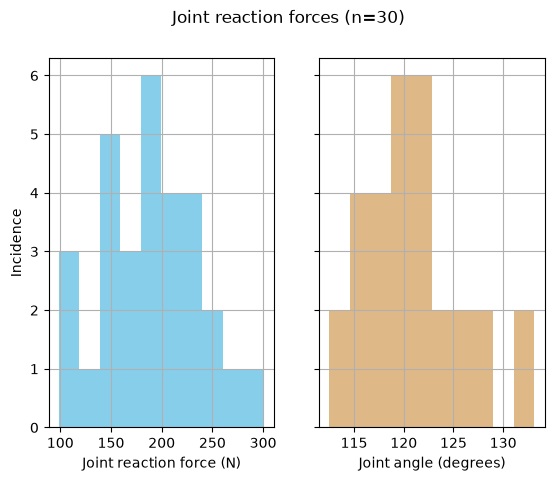

n=70: mean JRF magnitude = 184.4 N, mean JRF angle = 122.7 degrees


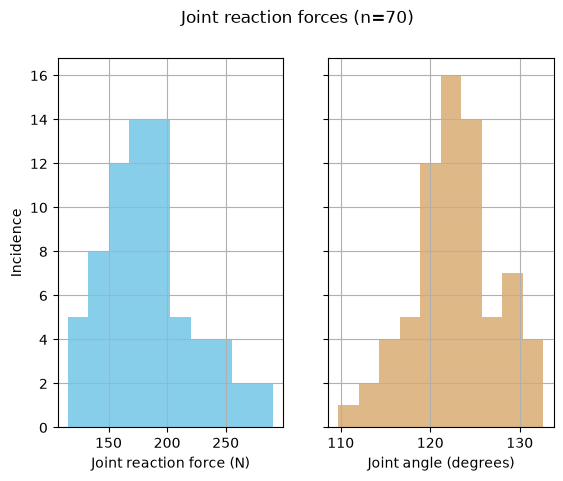

n=100: mean JRF magnitude = 193.3 N, mean JRF angle = 122.1 degrees


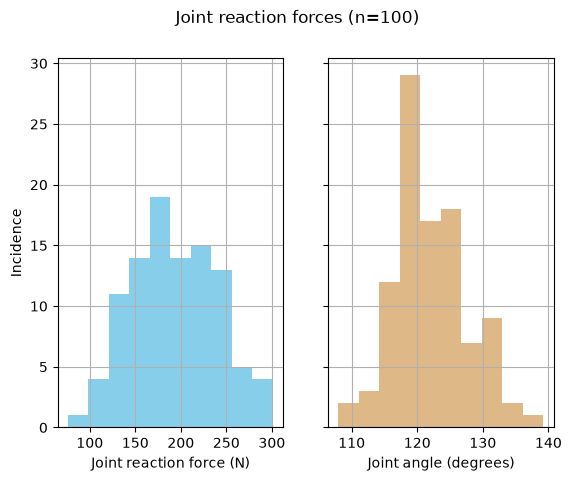

In [3]:
sample_sizes = [30, 70, 100];
results = {n: run_simulation(n, seed=n) for n in sample_sizes};

for n in sample_sizes:
    mag = results[n]['mag'];
    angled = results[n]['angled'];

    print(f"n={n}: mean JRF magnitude = {mag.mean():.1f} N, mean JRF angle = {angled.mean():.1f} degrees")

    fig, axs = plt.subplots(1, 2, sharey=True, edgecolor='blue')
    axs[0].hist(mag, bins=10, color='skyblue')
    axs[1].hist(angled, bins=10, color='burlywood')

    fig.suptitle(f"Joint reaction forces (n={n})")
    axs[0].set_xlabel("Joint reaction force (N)")
    axs[1].set_xlabel("Joint angle (degrees)")
    axs[0].set_ylabel("Incidence")
    for ax in axs:
        ax.grid(True)

    plt.show()

# keep the n=30 run available under the original variable names for the Muscle 4 cells below
F1_array, F2_array, F3_array, F4_array = results[30]['F1'], results[30]['F2'], results[30]['F3'], results[30]['F4'];
a_M4_array = results[30]['a_M4'];

Compile descriptive statistics (mean, SD, median) for the perturbed independent variables (using the n=100 run, as the largest and most population-representative sample), and descriptive statistics (mean, SD, median, max, min) for the joint reaction force magnitude at each sample size.

In [4]:
# Descriptive statistics for the independent variables (n=100 run)
iv_labels = {
    'ulna (c)': 'ulna', 
    'theta_M1 (BRA)': 'a_M1', 'theta_M2 (BIC)': 'a_M2', 'theta_M3 (BRD)': 'a_M3', 'theta_M4 (PRO)': 'a_M4',
    'l_M1 (BRA)': 'l_M1', 'l_M2 (BIC)': 'l_M2', 'l_M3 (BRD)': 'l_M3', 'l_M4 (PRO)': 'l_M4',
    'PCSA_M1 (BRA)': 'PCSA_M1', 'PCSA_M2 (BIC)': 'PCSA_M2', 'PCSA_M3 (BRD)': 'PCSA_M3', 'PCSA_M4 (PRO)': 'PCSA_M4',
}
angle_keys = {'a_M1', 'a_M2', 'a_M3', 'a_M4'}; # these are stored in radians, report in degrees

iv_rows = [];
for label, key in iv_labels.items():
    vals = results[100][key];
    if key in angle_keys:
        vals = np.rad2deg(vals);
    iv_rows.append({'Variable': label, 'Mean': vals.mean(), 'SD': vals.std(ddof=1), 'Median': np.median(vals)});

iv_stats = pd.DataFrame(iv_rows).set_index('Variable').round(3);
print("Independent variable descriptive statistics (n=100 sample; angles in degrees, lengths in cm, PCSA in cm^2)");
display(iv_stats)

# Descriptive statistics for the JRF magnitude at each sample size
jrf_rows = [];
for n in sample_sizes:
    mag = results[n]['mag'];
    jrf_rows.append({'n': n, 'Mean': mag.mean(), 'SD': mag.std(ddof=1), 'Median': np.median(mag),
                      'Max': mag.max(), 'Min': mag.min()});

jrf_stats = pd.DataFrame(jrf_rows).set_index('n').round(2);
print("\nJoint reaction force magnitude (N) descriptive statistics, by sample size");
display(jrf_stats)

Independent variable descriptive statistics (n=100 sample; angles in degrees, lengths in cm, PCSA in cm^2)


,Mean,SD,Median
Variable,,,
ulna (c),33.393,5.194,32.736
theta_M1 (BRA),80.261,2.581,80.341
theta_M2 (BIC),69.787,2.566,69.558
theta_M3 (BRD),17.927,2.786,17.809
theta_M4 (PRO),71.788,3.121,71.415
l_M1 (BRA),2.674,0.707,2.724
l_M2 (BIC),5.381,1.818,5.252
l_M3 (BRD),20.614,2.583,20.580
l_M4 (PRO),1.686,0.468,1.674



Joint reaction force magnitude (N) descriptive statistics, by sample size


,Mean,SD,Median,Max,Min
n,,,,,
30,188.89,50.05,192.03,300.70,98.59
70,184.36,38.94,176.59,290.24,115.30
100,193.32,47.41,188.96,301.08,75.91


Validate the correlation structure: report the realized (sampled) Pearson correlation between each variable and its moment-arm driver (n=100 run), alongside the assumed target $\rho$.

In [5]:
# Realized vs. target correlation coefficients (n=100 run)
r100 = run_simulation(100, seed=100);

def zscore(x):
    return (x - x.mean())/x.std();

pairs = [
    ('PCSA_M1 vs l_M1', r100['PCSA_M1'], r100['l_M1'], rho_PCSA_l),
    ('PCSA_M2 vs l_M2', r100['PCSA_M2'], r100['l_M2'], rho_PCSA_l),
    ('PCSA_M3 vs l_M3', r100['PCSA_M3'], r100['l_M3'], rho_PCSA_l),
    ('PCSA_M4 vs l_M4', r100['PCSA_M4'], r100['l_M4'], rho_PCSA_l),
    ('theta_M1 vs l_M1', r100['a_M1'], r100['l_M1'], rho_theta_l),
    ('theta_M2 vs l_M2', r100['a_M2'], r100['l_M2'], rho_theta_l),
    ('theta_M3 vs l_M3', r100['a_M3'], r100['l_M3'], rho_theta_l),
    ('theta_M4 vs l_M4', r100['a_M4'], r100['l_M4'], rho_theta_l),
    ('c vs composite limb size', r100['ulna'],
     (zscore(r100['l_M1']) + zscore(r100['l_M2']) + zscore(r100['l_M3']) + zscore(r100['l_M4']))/4,
     rho_c_l),
]

corr_rows = [{'Pair': label, 'Target rho': target, 'Realized r': np.corrcoef(x, y)[0, 1]}
             for label, x, y, target in pairs]
corr_table = pd.DataFrame(corr_rows).set_index('Pair').round(3);
display(corr_table)

,Target rho,Realized r
Pair,,
PCSA_M1 vs l_M1,0.50,0.564
PCSA_M2 vs l_M2,0.50,0.426
PCSA_M3 vs l_M3,0.50,0.571
PCSA_M4 vs l_M4,0.50,0.594
theta_M1 vs l_M1,0.15,0.040
theta_M2 vs l_M2,0.15,0.196
theta_M3 vs l_M3,0.15,0.199
theta_M4 vs l_M4,0.15,0.170
c vs composite limb size,0.60,0.651


Now examine the distribution of the fourth muscle's (pronator teres) force $F_4$ and its insertion angle $\theta_4$ across the Monte Carlo population (n=30 run), alongside the forces in muscles 1-3 (brachialis, biceps brachii, brachioradialis).

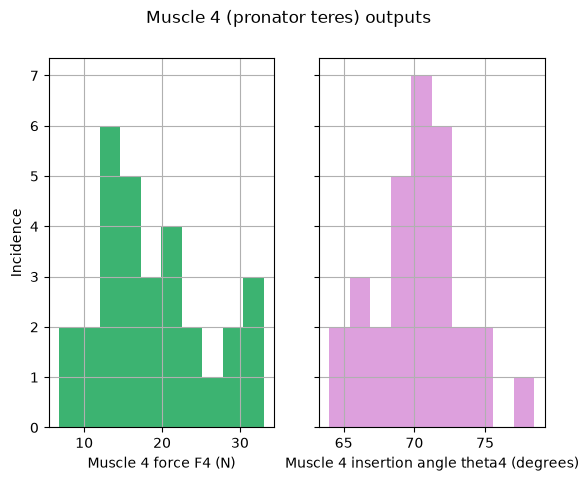

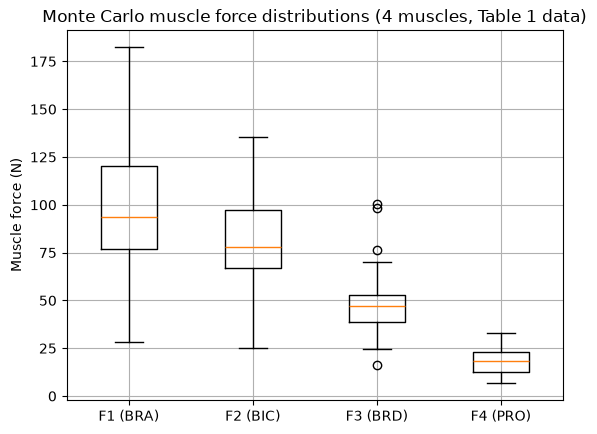

In [6]:
# Frequency distributions for Muscle 4 (pronator teres): force F4 and insertion angle theta4
fig, axs = plt.subplots(1, 2, sharey=True, edgecolor='blue')
axs[0].hist(F4_array, bins=10, color='mediumseagreen')
axs[1].hist(np.rad2deg(a_M4_array), bins=10, color='plum')

fig.suptitle("Muscle 4 (pronator teres) outputs")

axs[0].set_xlabel("Muscle 4 force F4 (N)")
axs[1].set_xlabel("Muscle 4 insertion angle theta4 (degrees)")
axs[0].set_ylabel("Incidence")

for ax in axs:
    ax.grid(True)

plt.show()

# Compare all four muscle forces side by side
fig2, ax2 = plt.subplots()
ax2.boxplot([F1_array, F2_array, F3_array, F4_array], tick_labels=['F1 (BRA)', 'F2 (BIC)', 'F3 (BRD)', 'F4 (PRO)'])
ax2.set_ylabel("Muscle force (N)")
ax2.set_title("Monte Carlo muscle force distributions (4 muscles, Table 1 data)")
ax2.grid(True)
plt.show()